# P5: Modelos Ocultos de Markov

**Contenido del notebook.**
1. Verificar numéricamente forward, backward, $\gamma_t(i)$ y Viterbi para el HMM de los ejercicios 1 y 2.
2. Implementar las recursiones de forma general.
3. Visualizar las cantidades sobre grillas/trellis.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=6, suppress=True)

In [2]:
# Estados matemáticos 1, 2 <-> índices de Python 0, 1
# Símbolos: x -> 0, z -> 1
# B[j, v] = P(Y_t=v | Q_t=j), usando índices de Python
pi = np.array([0.6, 0.4])
A = np.array([[0.7, 0.3],
              [0.4, 0.6]])
B = np.array([[0.9, 0.1],
              [0.2, 0.8]])

simbolo = {'x': 0, 'z': 1}
y = np.array([simbolo[s] for s in ['x', 'z', 'x']])

## 1. Forward

La recursión es

$$
\alpha_1(i)=\pi_i b_i(y_1),
\qquad
\alpha_t(j)=\left[\sum_i \alpha_{t-1}(i)a_{ij}\right]b_j(y_t).
$$

In [3]:
def forward(y, pi, A, B):
    T = len(y)
    N = len(pi)
    alpha = np.zeros((T, N))

    ### COMPLETAR inicialización
    #alpha[0] lo expresamos como alpha[0, :] (primera fila, todas las columnas)
    alpha[0, :] = pi * B[:, y[0]] #B[:, 0] -> Todas las filas de la primera columna

    for t in range(1, T):
        for j in range(N):
            ### COMPLETAR recursión
            alpha[t, j] = (alpha[t-1, :] @ A[:, j]) * B[j, y[t]]
            #Otra forma:
            #alpha[t, j] = np.sum(alpha[t-1] * A[:, j]) * B[j, y[t]]

            pass

    # COMPLETAR terminación
    prob = np.sum(alpha[-1, :], axis=0)
    return alpha, prob

alpha, prob = forward(y, pi, A, B)

print('alpha =')
print(alpha)
print(f'\np(y_1:T | lambda) = {prob:.6f}')

alpha =
[[0.54    0.08   ]
 [0.041   0.168  ]
 [0.08631 0.02262]]

p(y_1:T | lambda) = 0.108930


## 2. Backward

La recursión (hacia atrás) es

$$
\beta_T(i)=1,
\qquad
\beta_t(i)=\sum_j a_{ij}b_j(y_{t+1})\beta_{t+1}(j).
$$

In [4]:
def backward(y, A, B):
    T = len(y)
    N = A.shape[0]
    beta = np.zeros((T, N))

    ### COMPLETAR inicialización
    beta[-1] = 1

    for t in range(T - 2, -1, -1):
        for i in range(N):
            ### COMPLETAR recursión
            beta[t, i] = np.sum(A[i, :] * B[:, y[t+1]] * beta[t+1, :])
            pass

    return beta

beta = backward(y, A, B)

print('beta =')
print(beta)
print('\nVerificación:')
for t in range(len(y)):
    print(f't={t+1}: {np.sum(alpha[t] * beta[t]):.6f}')

beta =
[[0.1635 0.258 ]
 [0.69   0.48  ]
 [1.     1.    ]]

Verificación:
t=1: 0.108930
t=2: 0.108930
t=3: 0.108930


## 3. Probabilidades *a posteriori* de estado

$$
\gamma_t(i)
=
P(Q_t=i| Y_{1:T}=y_{1:T},\lambda)
=
\frac{\alpha_t(i)\beta_t(i)}{p(y_{1:T}|\lambda)}.
$$

In [5]:
### COMPLETAR 
gamma = alpha*beta/prob

print('gamma =')
print(gamma)
print('\nSuma por frame:')
print(np.sum(gamma, axis=1)) ### <-- COMPLETAR (verificar que cada fila sume 1)

gamma =
[[0.810521 0.189479]
 [0.259708 0.740292]
 [0.792344 0.207656]]

Suma por frame:
[1. 1. 1.]


## 4. Viterbi

Viterbi reemplaza la suma de forward por un máximo para así obtener la secuenca de estados óptima. Recordemos que tenemos la variable de Viterbi y el *puntero*:

$$
\delta_t(j)=\max_i [\delta_{t-1}(i)a_{ij}]b_j(y_t),
$$

$$
\psi_t(j)=\operatorname*{argmax}_i \delta_{t-1}(i)a_{ij}.
$$

In [6]:
def viterbi(y, pi, A, B):
    T = len(y)
    N = len(pi)
    delta = np.zeros((T, N))
    psi = np.zeros((T, N), dtype=int)

    ### COMPLETAR inicialización
    delta[0, :] = pi * B[:, y[0]] 
    psi[0] = -1

    for t in range(1, T):
        for j in range(N):
            ### COMPLETAR:
            tmp = gamma[t-1, :] * A[:, j]
            psi[t, j] = np.argmax(tmp) 
            delta[t, j] = np.max(tmp) * B[j, y[t]]
            pass

    path = np.zeros(T, dtype=int)
    ### COMPLETAR terminación 
    path[-1] = np.argmax(delta[-1, :])
    for t in range (0, T-1):
        path[t] = psi[t+1, path[t+1]]

    P_star = np.max(delta[-1, :])
    return delta, psi, path, P_star

delta, psi, path, P_star = viterbi(y, pi, A, B)

print('delta =')
print(delta)
print('\npsi =')
print(psi + 1)  # +1 para mostrar estados 1,2 como en el escrito
print(f'\nCamino Viterbi q* = {path + 1}')
print(f'P* = {P_star:.6f}')

gamma_decode = np.argmax(gamma, axis=1)
print(f'\nDecodificación usando gamma = {gamma_decode + 1}')

delta =
[[0.54     0.08    ]
 [0.056736 0.194525]
 [0.266505 0.088835]]

psi =
[[0 0]
 [1 1]
 [2 2]]

Camino Viterbi q* = [1 2 1]
P* = 0.266505

Decodificación usando gamma = [1 2 1]


## 5. Visualización

Cada columna es un frame y cada fila un estado. Forward tiene en cuenta todos los caminos posibles, mientras que Viterbi elige el mejor.

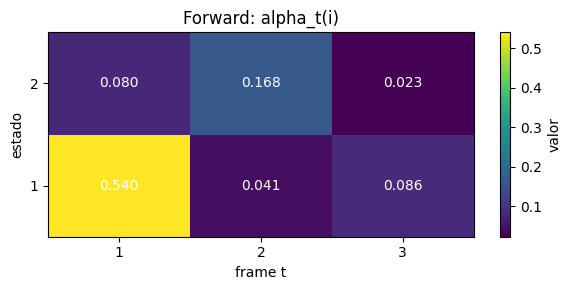

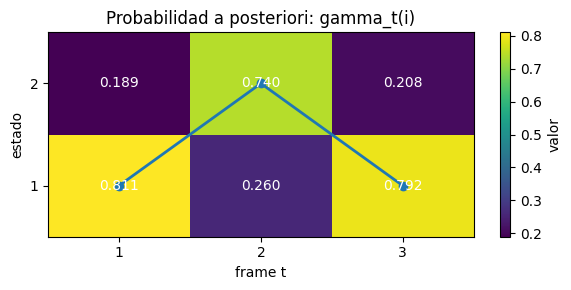

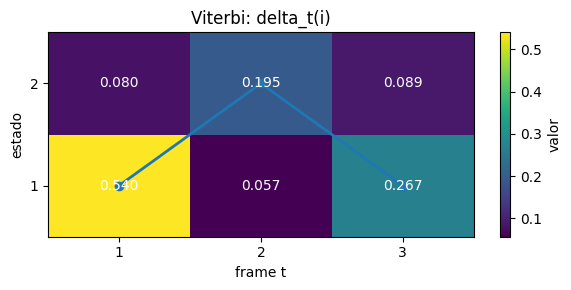

In [7]:
def plot_trellis(matriz, title, path=None):
    fig, ax = plt.subplots(figsize=(6, 3))
    im = ax.imshow(matriz.T, aspect='auto', origin='lower')
    ax.set_xlabel('frame t')
    ax.set_ylabel('estado')
    ax.set_xticks(range(matriz.shape[0]))
    ax.set_xticklabels(range(1, matriz.shape[0] + 1))
    ax.set_yticks(range(matriz.shape[1]))
    ax.set_yticklabels(range(1, matriz.shape[1] + 1))
    ax.set_title(title)
    for t in range(matriz.shape[0]):
        for i in range(matriz.shape[1]):
            ax.text(t, i, f'{matriz[t, i]:.3f}', ha='center', va='center', color='white')
    if path is not None:
        ax.plot(range(len(path)), path, 'o-', linewidth=2)
    plt.colorbar(im, ax=ax, label='valor')
    plt.tight_layout()
    plt.show()

plot_trellis(alpha, 'Forward: alpha_t(i)')
plot_trellis(gamma, 'Probabilidad a posteriori: gamma_t(i)', path=path)
plot_trellis(delta, 'Viterbi: delta_t(i)', path=path)

**Conclusión:** <mark>COMPLETAR</mark>.